# 05.1 Time-Series Live Scoring

Scoring de mercados activos con `PriceSequenceGRU`, más una evaluación backtest-style sobre resueltos.

**Objetivo**
- cargar el checkpoint TS ya entrenado
- puntuar mercados activos usando solo `price_history`
- generar señales con las mismas reglas del baseline
- revisar cómo se comporta el score sobre una muestra de resueltos

**Prerequisito**
Este notebook asume que ya existe `data/models/price_sequence_gru/best_ts_gru_model.pt`.


## 1. Setup y carga de artefactos

Trabajamos con el snapshot local de `data/raw/`, sin depender de descargas nuevas. Eso mantiene la comparación contra el baseline en el mismo corte de datos.

In [6]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.config import load_config

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

cfg = load_config(str(ROOT / 'config' / 'config.yaml'))
MODELS = ROOT / 'data' / 'models'
REGISTRY = MODELS / 'registry'
MODEL_NAME = 'price_sequence_gru'

comparison = json.loads((REGISTRY / 'model_comparison.json').read_text())
live_df = pd.read_csv(REGISTRY / 'live_scores.csv')
live_summary = json.loads((REGISTRY / 'live_scoring_summary.json').read_text())
test_metrics = comparison['models'][MODEL_NAME]['test']

df_scores = live_df[live_df['model_name'] == MODEL_NAME].copy().sort_values('ev_per_share', ascending=False)
print(f'Modelo: {MODEL_NAME}')
print(f'Rows live: {len(df_scores):,}')


Modelo: price_sequence_gru
Rows live: 534


## 2. Cliente local y carga de datos

El cliente local reproduce la interfaz del fetcher real, pero usa archivos cacheados. Así el notebook es reproducible y no depende de la red.

In [7]:
RAW = ROOT / 'data' / 'raw'

with open(RAW / 'active_markets.json') as f:
    active_markets = json.load(f)
with open(RAW / 'resolved_markets.json') as f:
    resolved_markets = json.load(f)
with open(RAW / 'price_histories.json') as f:
    price_histories = json.load(f)

print(f'Mercados activos cacheados: {len(active_markets):,}')
print(f'Price histories cacheados: {len(price_histories):,}')
print(f'Rows live en artefacto TS: {len(df_scores):,}')


Mercados activos cacheados: 900
Price histories cacheados: 24,900
Rows live en artefacto TS: 534


## 3. Scoring de mercados activos

El modelo TS usa solo historia de precios. Si un mercado no tiene suficientes puntos válidos, se omite. Después aplicamos exactamente las mismas reglas de señal que en el baseline.

In [8]:
top_signals = df_scores[df_scores['signal'] != 'HOLD'].head(20)
print(f'Mercados puntuados por TS-GRU: {len(df_scores):,}')
print(top_signals[['signal', 'price_yes', 'p_yes_calibrated', 'ev_per_share', 'expected_roi_capped', 'days_to_end']].head(10))


Mercados puntuados por TS-GRU: 534
         signal  price_yes  p_yes_calibrated  ev_per_share  \
567  STRONG BUY     0.0850          0.347826      0.262826   
585  STRONG BUY     0.1250          0.371917      0.246917   
593  STRONG BUY     0.0315          0.273128      0.241628   
596  STRONG BUY     0.0335          0.273128      0.239628   
603  STRONG BUY     0.1350          0.371917      0.236917   
605  STRONG BUY     0.1350          0.371917      0.236917   
606  STRONG BUY     0.0365          0.273128      0.236628   
607  STRONG BUY     0.0365          0.273128      0.236628   
608  STRONG BUY     0.0370          0.273128      0.236128   
611  STRONG BUY     0.1370          0.371917      0.234917   

     expected_roi_capped  days_to_end  
567             3.092072    16.882237  
585             1.975332    18.048904  
593             5.000000    18.048904  
596             5.000000    18.048904  
603             1.754937     2.878765  
605             1.754937    18.048904  
60

## 4. Lectura rápida de señales

Esta tabla sirve para ver si el modelo está concentrando score en pocos mercados o si todo quedó en `HOLD`.

In [9]:
signal_counts = df_scores['signal'].value_counts().reindex(['STRONG BUY', 'BUY', 'HOLD'], fill_value=0)
print(signal_counts)


signal
STRONG BUY     52
BUY             0
HOLD          482
Name: count, dtype: int64


## 5. Distribución de scores y señales

Dos chequeos rápidos útiles:
- cómo se reparte el `model_score` sobre el universo activo
- cuántos mercados sobreviven a los filtros operativos

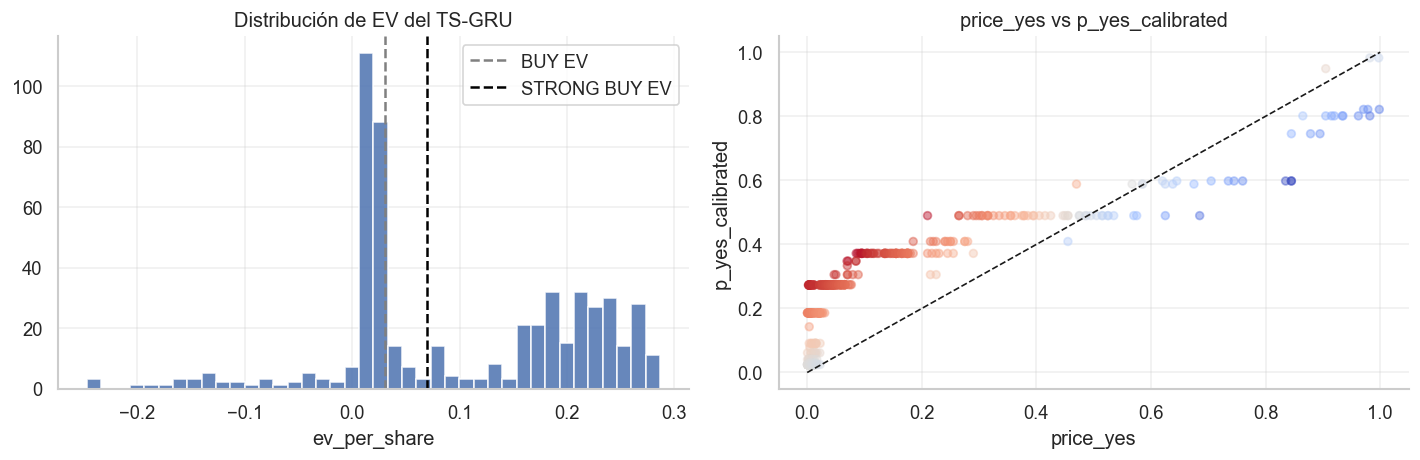

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(df_scores['ev_per_share'], bins=40, color=PALETTE[0], alpha=0.85)
ax.axvline(cfg['scoring']['buy_ev_threshold'], color='gray', linestyle='--', lw=1.5, label='BUY EV')
ax.axvline(cfg['scoring']['strong_buy_ev_threshold'], color='black', linestyle='--', lw=1.5, label='STRONG BUY EV')
ax.set_title('Distribución de EV del TS-GRU')
ax.set_xlabel('ev_per_share')
ax.legend()

ax = axes[1]
ax.scatter(df_scores['price_yes'], df_scores['p_yes_calibrated'], c=df_scores['ev_per_share'], cmap='coolwarm', alpha=0.45, s=22)
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_title('price_yes vs p_yes_calibrated')
ax.set_xlabel('price_yes')
ax.set_ylabel('p_yes_calibrated')

plt.tight_layout()
plt.show()


## 6. Evaluación backtest-style en resueltos

No es un backtest de ejecución real, pero sí una lectura útil de consistencia: truncamos la serie al snapshot histórico, scoreamos y medimos win rate por señal.

In [11]:
bucket_rows = []
for bucket_name, bucket_payload in test_metrics.get('by_horizon', {}).items():
    bucket_rows.append({
        'bucket': bucket_name,
        'count': bucket_payload.get('count', 0),
        'brier': bucket_payload.get('probability_metrics', {}).get('brier'),
        'top_k_avg_realized_pnl': bucket_payload.get('ev_metrics', {}).get('top_k_avg_realized_pnl'),
        'top_k_hit_rate': bucket_payload.get('ev_metrics', {}).get('top_k_hit_rate'),
    })
df_bt = pd.DataFrame(bucket_rows)
display(df_bt.round(4))


,bucket,count,brier,top_k_avg_realized_pnl,top_k_hit_rate
0,short_1_3d,2380,0.0243,-0.0368,0.0
1,medium_4_14d,2380,0.0255,-0.0423,0.0
2,long_15plus,1167,0.0352,-0.0490,0.0


## 7. Diagnóstico de calibración por señal

La idea aquí es ver si `STRONG BUY` realmente concentra un win rate mayor que `BUY`, y ambos mayor que la base de la muestra.

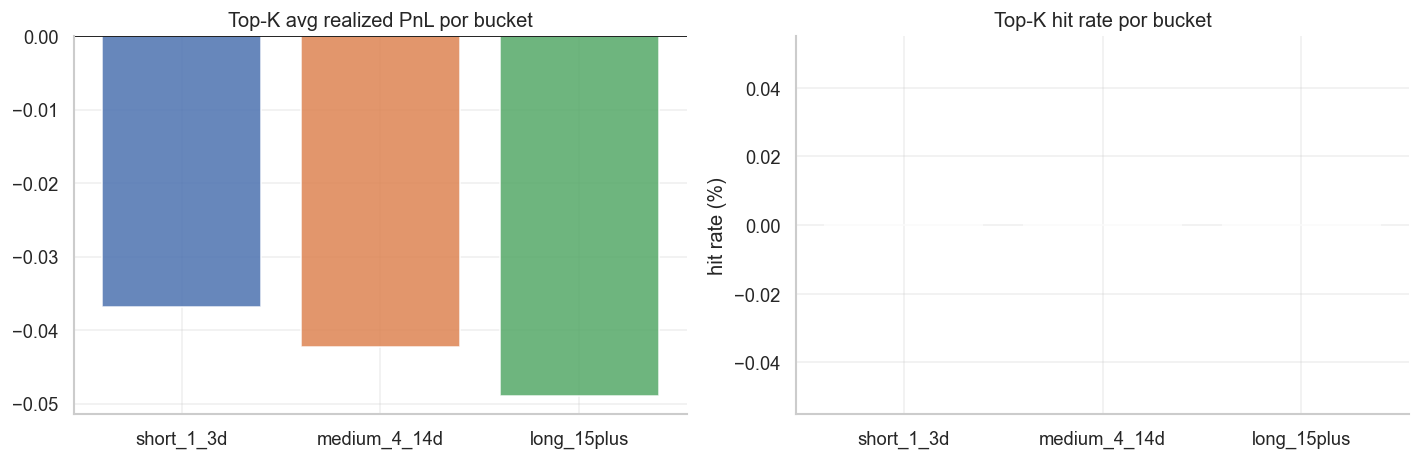

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(df_bt['bucket'], df_bt['top_k_avg_realized_pnl'], color=PALETTE[:len(df_bt)], alpha=0.85)
axes[0].axhline(0, color='black', lw=1)
axes[0].set_title('Top-K avg realized PnL por bucket')
axes[1].bar(df_bt['bucket'], 100 * df_bt['top_k_hit_rate'], color=PALETTE[:len(df_bt)], alpha=0.85)
axes[1].set_title('Top-K hit rate por bucket')
axes[1].set_ylabel('hit rate (%)')
plt.tight_layout()
plt.show()


## 8. Qué mirar antes de comparar con el baseline

Este notebook queda “bien” si ves algo como esto:
- cobertura razonable en activos
- algunas señales distintas de `HOLD`
- win rate creciente al subir el score o la fuerza de la señal

Con eso, el siguiente paso es `05_2_model_comparison.ipynb`.